In [1]:
import joblib
import pandas as pd
import numpy as np
from plotnine import *
import patchworklib as pw

<Figure size 100x100 with 0 Axes>

In [75]:
pkl_file = "../data/test.pkl"
term_index=5

In [76]:
pre_res = joblib.load(pkl_file)
terms = pre_res.res2d.Term
term = terms[term_index]

hits = pre_res.results[term]["hits"]
resdata = pd.DataFrame({
    "res": pre_res.results[term]["RES"],
    "index": range(len(pre_res.results[term]["RES"]))
})

In [77]:
max(resdata["res"])

0.0007083156253130385

In [4]:
nes = pre_res.results[term]["nes"]
pval = pre_res.results[term]["pval"]
fdr = pre_res.results[term]["fdr"]

In [5]:
postion_left = len(resdata)*0.80
postion_top = max(resdata["res"])*0.80

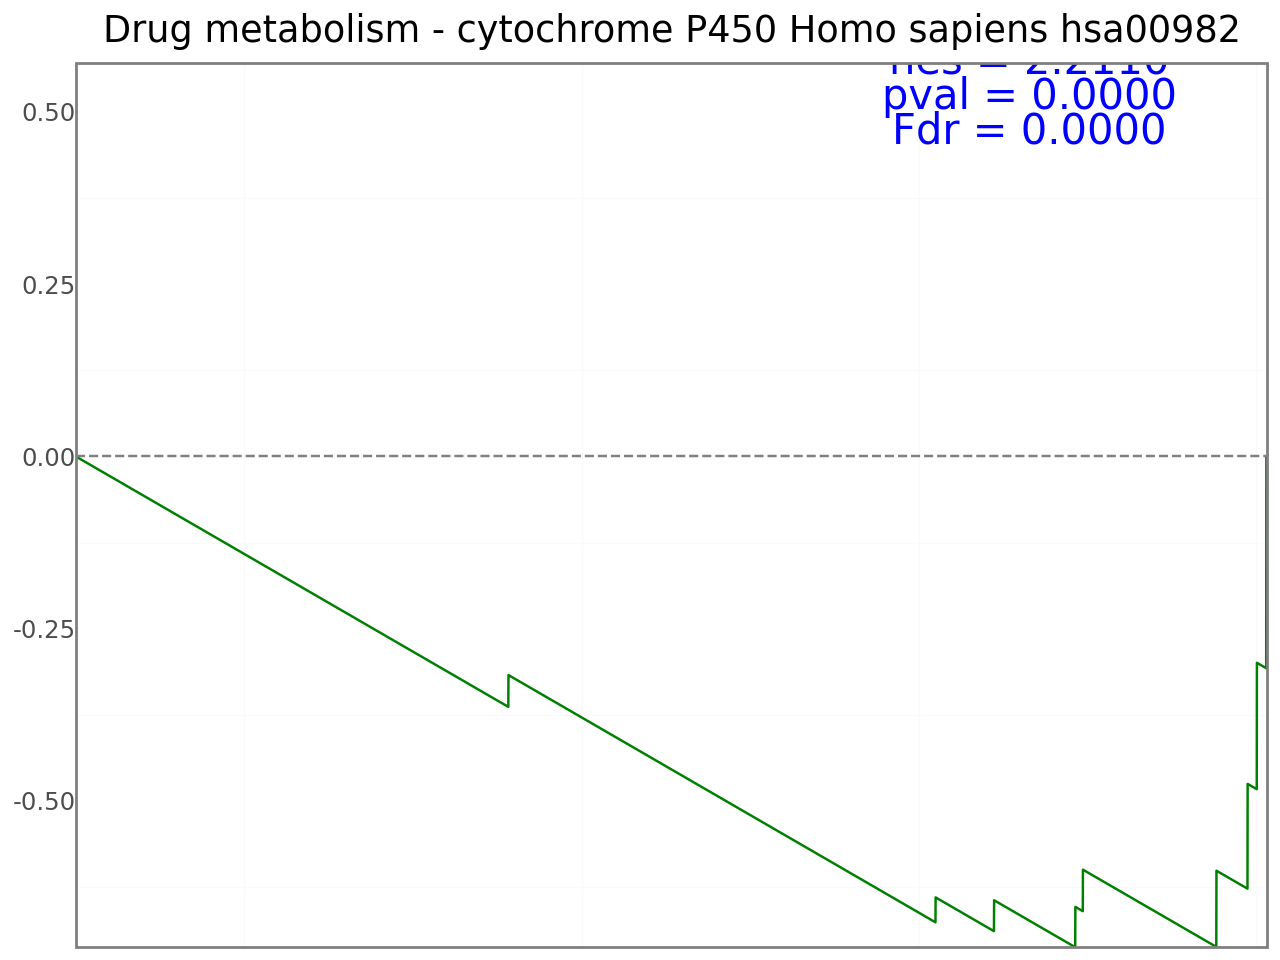

In [84]:
(ggplot(resdata, aes(x='index', y='res')) +
          geom_line(color="green") +
          theme_bw() +
          geom_hline(yintercept=0, color="grey", size=0.5,linetype="dashed")+
          theme(axis_text_x=element_blank(),
                legend_position="none",
                axis_ticks=element_blank(),
                panel_background=element_blank(),panel_grid_major=element_blank()) +
         annotate(
        "text",
        x=postion_left,
        y=postion_top,
        label=f"nes = {nes:.4f}",
        color="blue",
        size=15,
        )+
         annotate(
        "text",
        x=postion_left,
        y=postion_top-0.05,
        label=f"pval = {pval:.4f}",
        color="blue",
        size=15,
        )+
         annotate(
        "text",
        x=postion_left,
        y=postion_top-0.1,
        label=f"Fdr = {fdr:.4f}",
        color="blue",
        size=15,
        )+
          xlab('') + ylab('') +
          ggtitle(term) +
          scale_x_continuous(expand=(0, 0)) +
          scale_y_continuous(expand=(0, 0)))

In [57]:
import pandas as pd
import numpy as np
from matplotlib import colors

def compute_heat_blocks(gsdata, htCol=("red", "blue"), htHeight=1.0):
    all_blocks = []

    for setid in gsdata["Description"].unique():
        tmp = gsdata[gsdata["Description"] == setid].copy()

        # Step 1: 计算 rev(cumsum(position))
        rev_pos = tmp["position"].values[::-1]
        rev_cumsum = np.cumsum(rev_pos)

        # Step 2: 划分为 9 段区间
        v = np.linspace(1, rev_pos.sum(), 9)
        inv = np.searchsorted(v, rev_cumsum, side="right")

        if inv.min() == 0:
            inv += 1

        inv = inv
        tmp = tmp.reset_index(drop=True)
        tmp["inv"] = inv

        # Step 3: 为连续 inv 的 group 分配 xmin/xmax
        tmp["group"] = (tmp["inv"] != tmp["inv"].shift()).cumsum()

        blocks = []
        for _, g in tmp.groupby("group"):
            xmin = g.index.min()
            xmax = g.index.max() + 1  # +1 to make it closed on right
            color_idx = g["inv"].iloc[0]
            blocks.append({
                "xmin": xmin,
                "xmax": xmax,
                "ymin": 0,
                "ymax": htHeight,
                "col": color_idx,
                "Description": setid
            })

        # Step 4: 分配颜色（共10种颜色）
        cmap = colors.LinearSegmentedColormap.from_list("custom_gradient", [htCol[0], "white", htCol[1]])
        color_list = [colors.to_hex(cmap(i / 10)) for i in range(10)]

        block_df = pd.DataFrame(blocks)
        block_df["col"]= block_df["col"] -1
        block_df["col"] = block_df["col"].apply(lambda i: color_list[i])

        #all_blocks.append(block_df)

    return block_df


In [39]:
htCol=("red", "blue")
cmap = colors.LinearSegmentedColormap.from_list("custom_gradient", [htCol[0], "white", htCol[1]])
color_list = [colors.to_hex(cmap(i / 10)) for i in range(10)]

In [53]:
color_list

['#ff0000',
 '#ff3232',
 '#ff6666',
 '#ff9898',
 '#ffcccc',
 '#fefeff',
 '#ccccff',
 '#9898ff',
 '#6666ff',
 '#3232ff']

In [44]:
heatmap_data["col"]

0    10
1     9
2     8
3     7
4     6
5     5
6     4
7     3
8     2
9     1
Name: col, dtype: int64

In [78]:
np.mean(data)

NameError: name 'mean' is not defined

In [13]:
pre_res.results[term].keys()

dict_keys(['name', 'es', 'nes', 'pval', 'fdr', 'fwerp', 'tag %', 'gene %', 'lead_genes', 'matched_genes', 'hits', 'RES'])

In [14]:
pre_res.results[term]["hits"]

[0,
 4,
 33,
 38,
 40,
 45,
 55,
 117,
 139,
 154,
 188,
 228,
 258,
 284,
 351,
 506,
 579,
 593,
 687,
 837,
 977,
 1071,
 1174,
 1265,
 1301,
 1491,
 1613,
 2017,
 2380,
 2475,
 2516,
 2989,
 3896,
 4569,
 4919,
 5207,
 5359,
 6229,
 6300,
 6496,
 6602,
 6789,
 6932,
 6987]

In [19]:
gsdata = pd.DataFrame({
    "position": [0]*len(resdata),
})
#blocks = compute_heat_blocks(gsdata)
#print(blocks)
gsdata["Description"] = term
gsdata["position"][pre_res.results[term]["hits"]] = 1
#blocks = compute_heat_blocks(gsdata)
print(gsdata)

      position                                     Description
0            1  ECM-receptor interaction Homo sapiens hsa04512
1            0  ECM-receptor interaction Homo sapiens hsa04512
2            0  ECM-receptor interaction Homo sapiens hsa04512
3            0  ECM-receptor interaction Homo sapiens hsa04512
4            1  ECM-receptor interaction Homo sapiens hsa04512
...        ...                                             ...
7063         0  ECM-receptor interaction Homo sapiens hsa04512
7064         0  ECM-receptor interaction Homo sapiens hsa04512
7065         0  ECM-receptor interaction Homo sapiens hsa04512
7066         0  ECM-receptor interaction Homo sapiens hsa04512
7067         0  ECM-receptor interaction Homo sapiens hsa04512

[7068 rows x 2 columns]


In [58]:
heatmap_data = compute_heat_blocks(gsdata)

In [59]:
heatmap_data

,xmin,xmax,ymin,ymax,col,Description
0,0,80,0,1.0,#ff0000,ECM-receptor interaction Homo sapiens hsa04512
1,80,838,0,1.0,#ff3232,ECM-receptor interaction Homo sapiens hsa04512
2,838,3171,0,1.0,#ff6666,ECM-receptor interaction Homo sapiens hsa04512
3,3171,5454,0,1.0,#ff9898,ECM-receptor interaction Homo sapiens hsa04512
4,5454,5996,0,1.0,#ffcccc,ECM-receptor interaction Homo sapiens hsa04512
5,5996,6488,0,1.0,#fefeff,ECM-receptor interaction Homo sapiens hsa04512
6,6488,6879,0,1.0,#ccccff,ECM-receptor interaction Homo sapiens hsa04512
7,6879,7022,0,1.0,#9898ff,ECM-receptor interaction Homo sapiens hsa04512
8,7022,7067,0,1.0,#6666ff,ECM-receptor interaction Homo sapiens hsa04512
9,7067,7068,0,1.0,#3232ff,ECM-receptor interaction Homo sapiens hsa04512


In [5]:
x_vals = np.linspace(0, len(resdata), len(resdata) * 10)
bg_df = pd.DataFrame({'x': x_vals})
bg_df['y'] = 0
bg_df['fill'] = bg_df['x']

p2 = (ggplot() +
        geom_vline(xintercept=hits, color='black') +
        xlim(0, len(resdata)-1) +
        scale_x_continuous(expand=(0, 0)) +
          geom_tile(data=bg_df, mapping=aes(x='x', y='y', fill='fill'),
                    width=0.1, height=10, alpha=0.4) +
          scale_fill_gradient(low="lightblue", high="purple") +
          theme(legend_position="none",
                axis_text=element_blank(),
                axis_ticks=element_blank(),
                axis_title=element_blank(),
                panel_background=element_blank()) +
          scale_y_continuous(expand=(0, 0)) +
          xlab('') + ylab('') +
          guides(color=False, fill=False, shape=False, size=False))

## fix plot

In [66]:
p2 = (ggplot() +
 geom_rect(aes(xmin="xmin", xmax="xmax", ymin="ymin", ymax="ymax",fill="col"),data=heatmap_data)+
 geom_vline(xintercept=hits, color='black') +
 scale_fill_identity()+
 scale_y_continuous(expand=(0, 0))+
 scale_x_continuous(expand=(0, 0))+
 theme(legend_position="none",
                axis_text=element_blank(),
                axis_ticks=element_blank(),
                axis_title=element_blank(),
                panel_background=element_blank())
 )

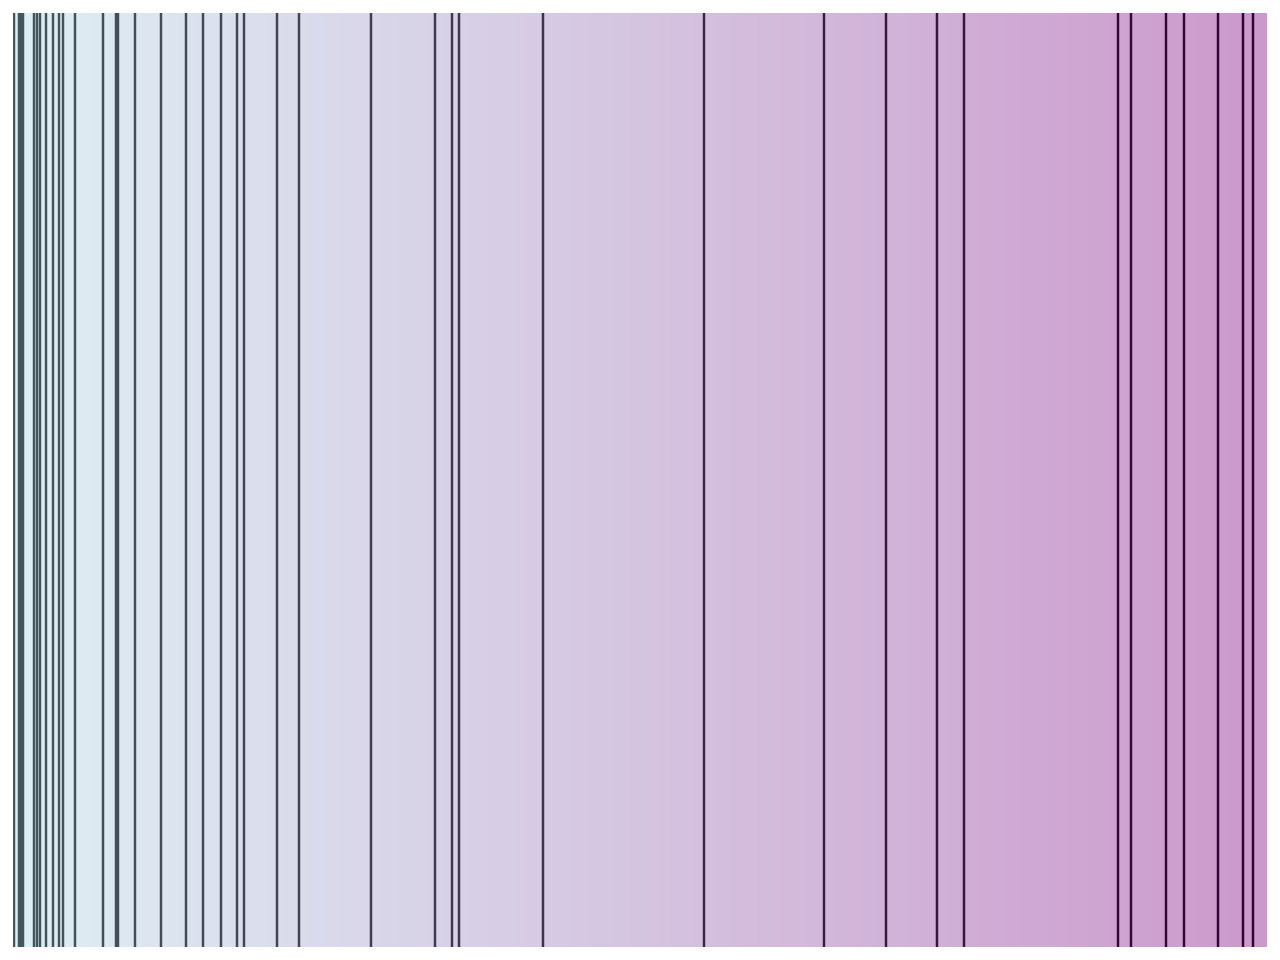

In [9]:
p2

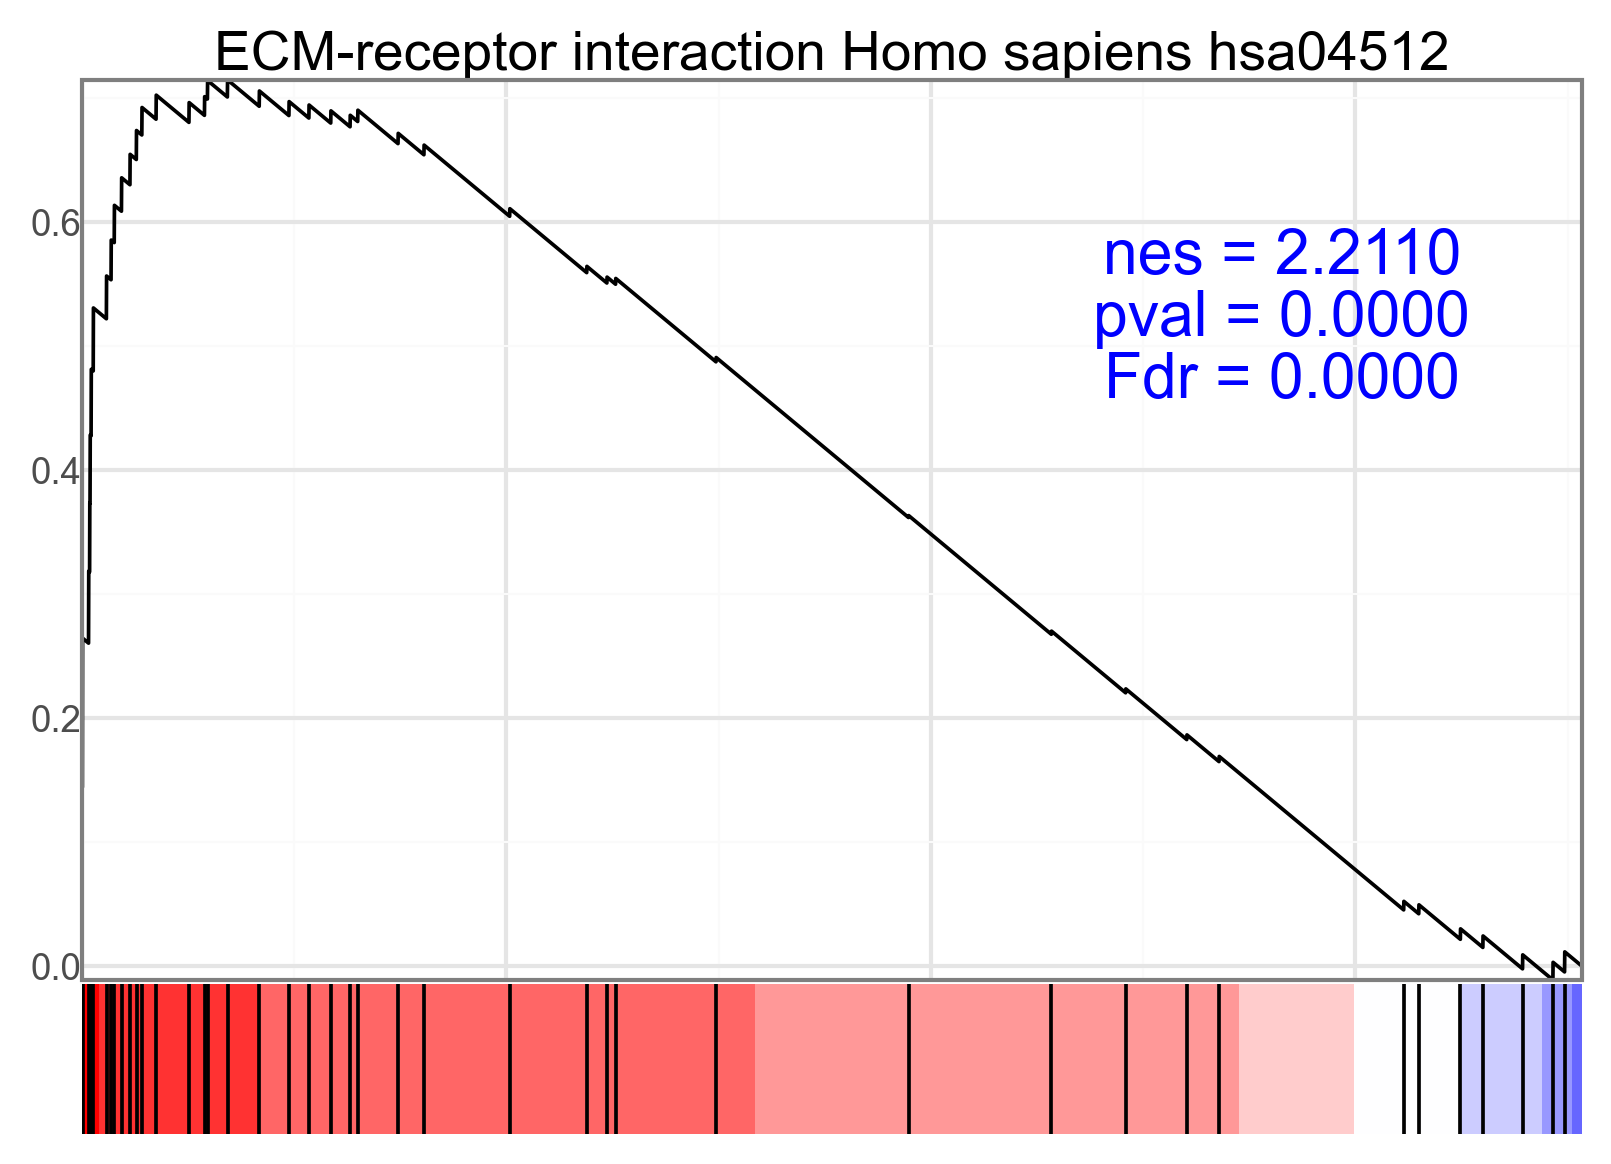

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [69]:
f1 = pw.load_ggplot(p1, figsize=(5, 3))
f2 = pw.load_ggplot(p2, figsize=(5, 0.5))
pw.vstack(f2, f1, margin=0)

In [7]:
def plot_gsea_result(pkl_file, output_file="gsea_plot.png", term_index=1):
    """
    Plot GSEA result from a .pkl file.

    Args:
        pkl_file (str): Path to the .pkl file (GSEAPy prerank result)
        output_file (str): Output file path (default: gsea_plot.png)
        term_index (int): Index of the term to plot (default: 1)
    """
    pre_res = joblib.load(pkl_file)
    terms = pre_res.res2d.Term
    term = terms[term_index]

    hits = pre_res.results[term]["hits"]
    resdata = pd.DataFrame({
        "res": pre_res.results[term]["RES"],
        "index": range(len(pre_res.results[term]["RES"]))
    })

    # Line plot
    p1 = (ggplot(resdata, aes(x='index', y='res')) +
          geom_line() +
          theme_bw() +
          theme(axis_text_x=element_blank(),
                legend_position="none",
                axis_ticks=element_blank(),
                panel_background=element_blank()) +
          xlab('') + ylab('') +
          ggtitle(term) +
          scale_x_continuous(expand=(0, 0)) +
          scale_y_continuous(expand=(0, 0)))

    # Background & vertical lines
    x_vals = np.linspace(0, len(resdata), len(resdata) * 10)
    bg_df = pd.DataFrame({'x': x_vals})
    bg_df['y'] = 0
    bg_df['fill'] = bg_df['x']

    p2 = (ggplot() +
          geom_vline(xintercept=hits, color='black') +
          xlim(0, len(resdata)-1) +
          scale_x_continuous(expand=(0, 0)) +
          geom_tile(data=bg_df, mapping=aes(x='x', y='y', fill='fill'),
                    width=0.1, height=10, alpha=0.4) +
          scale_fill_gradient(low="lightblue", high="purple") +
          theme(legend_position="none",
                axis_text=element_blank(),
                axis_ticks=element_blank(),
                axis_title=element_blank(),
                panel_background=element_blank()) +
          scale_y_continuous(expand=(0, 0)) +
          xlab('') + ylab('') +
          guides(color=False, fill=False, shape=False, size=False))

    # Combine
    f1 = pw.load_ggplot(p1, figsize=(5, 3))
    f2 = pw.load_ggplot(p2, figsize=(5, 0.5))
    pw.vstack(f2, f1, margin=0).savefig(output_file)
    print(f"✅ Plot saved to {output_file}")
plot_gsea_result(pkl_file)

✅ Plot saved to gsea_plot.png


<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [8]:
plot_gsea_result(pkl_file)

✅ Plot saved to gsea_plot.png


<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>